In [68]:
# FAZA 1

import pandas as pd
import numpy as np

# Učitavanje podataka sa GitHub-a
url = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv/matches.csv"
df = pd.read_csv(url)

df.to_csv('data/raw/matches.csv', index=False)

# Dimenzije skupa
print(f"Broj utakmica (redova): {df.shape[0]}")
print(f"Broj atributa (kolona): {df.shape[1]}")

# Ispis prvih 5 redova tabele
df.head()


Broj utakmica (redova): 1248
Broj atributa (kolona): 37


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


Zadržano 5 kolona: (1248, 5)

Nema nedostajućih vrednosti!


  home_team_name away_team_name   stage_name            tournament_name  \
0         France         Mexico  group stage  1930 FIFA Men's World Cup   
1  United States        Belgium  group stage  1930 FIFA Men's World Cup   
2     Yugoslavia         Brazil  group stage  1930 FIFA Men's World Cup   
3        Romania           Peru  group stage  1930 FIFA Men's World Cup   
4      Argentina         France  group stage  1930 FIFA Men's World Cup   

          result  
0  home team win  
1  home team win  
2  home team win  
3  home team win  
4  home team win  

Distribucija ishoda utakmica:
  home team win: 703
  away team win: 335
  draw: 210

Procentualno:
  home team win: 56.33%
  away team win: 26.84%
  draw: 16.83%


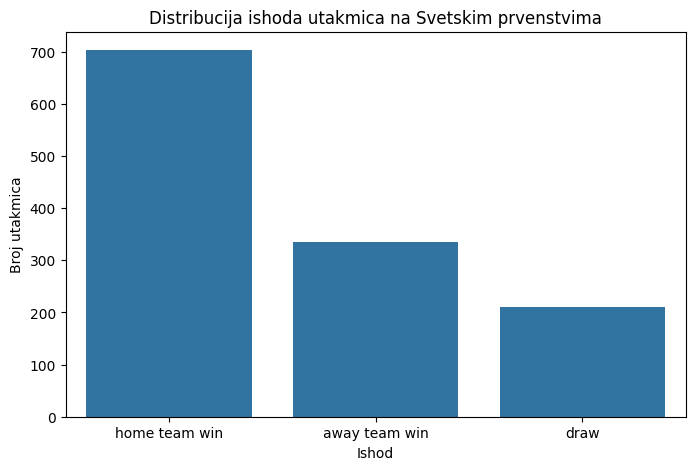

In [69]:
#FAZA 2 - PREPROCESIRANJE PODATAKA

# Uklanjanje nebitnih kolona

# Zadržavamo samo 5 kolona:
# home_team_name, away_team_name - koji timovi igraju
# stage_name - faza takmičenja (grupna/nokaut)
# tournament_name - za izvlačenje godine
# result - ciljna promenljiva
# home_goals, away_goals - poznati tek nakon utakmice
# date, city, stadium, win_conditions, id - nisu relevantni

df_selected = df[[
    'home_team_name',
    'away_team_name',
    'stage_name',
    'tournament_name',
    'result'
]].copy()

print("Zadržano 5 kolona:", df_selected.shape)

# Provera nedostajućih vrednosti
null_counts = df_selected.isnull().sum()
if null_counts.sum() == 0:
    print("\nNema nedostajućih vrednosti!")
else:
    print(null_counts[null_counts > 0])

# Prikaz preostalih kolona
print("\n")
print(df_selected.head())

# Distribucija ciljne promenljive (result)
print("\nDistribucija ishoda utakmica:")

counts = df_selected['result'].value_counts()
for ishod, broj in counts.items():
    print(f"  {ishod}: {broj}")

print("\nProcentualno:")
procenti = df_selected['result'].value_counts(normalize=True) * 100
for ishod, proc in procenti.items():
    print(f"  {ishod}: {proc:.2f}%")

# Vizuelizacija distribucije
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_selected, x='result', order=df_selected['result'].value_counts().index)
plt.title('Distribucija ishoda utakmica na Svetskim prvenstvima')
plt.xlabel('Ishod')
plt.ylabel('Broj utakmica')
plt.show()

In [70]:
#FAZA 3 - FEATURE ENGINEERING

# Učitavanje kolona potrebnih za računanje
df_full = df[['home_team_name', 'away_team_name', 'stage_name',
              'tournament_name', 'result', 'home_team_score', 'away_team_score',
              'match_date']].copy()

# Konvertovanje datuma u datetime format
df_full['match_date'] = pd.to_datetime(df_full['match_date'])

# Izdvajanje godine
df_full['year'] = df_full['tournament_name'].str.extract(r'(\d{4})').astype(int)

# Sortiranje po datumu
df_full = df_full.sort_values('match_date').reset_index(drop=True)

print("Podaci sortirani po datumu!")
print(df_full[['match_date', 'home_team_name', 'away_team_name']].head(10))

# Računanje forme domaćina
def calculate_home_form_with_date(df):
    """Računa prosek golova domaćina u poslednje 3 utakmice PRE ove utakmice"""
    form = []
    for idx, row in df.iterrows():
        team = row['home_team_name']
        current_date = row['match_date']
        current_tournament = row['tournament_name']

        # Pronalazi prethodne utakmice
        prev_matches = df[(df['tournament_name'] == current_tournament) &
                          (df['home_team_name'] == team) &
                          (df['match_date'] < current_date) &
                          (df.index < idx)]
        prev_matches = prev_matches.tail(3)

        if len(prev_matches) == 0:
            form.append(0.0)
        else:
            avg_goals = prev_matches['home_team_score'].mean()
            form.append(avg_goals)
    return form

# Računanje forme gosta
def calculate_away_form_with_date(df):
    """Računa prosek golova gosta u poslednje 3 utakmice PRE ove utakmice"""
    form = []
    for idx, row in df.iterrows():
        team = row['away_team_name']
        current_date = row['match_date']
        current_tournament = row['tournament_name']

        # Pronalazi prethodne utakmice
        prev_matches = df[(df['tournament_name'] == current_tournament) &
                          (df['away_team_name'] == team) &
                          (df['match_date'] < current_date) &
                          (df.index < idx)]
        prev_matches = prev_matches.tail(3)

        if len(prev_matches) == 0:
            form.append(0.0)
        else:
            avg_goals = prev_matches['away_team_score'].mean()
            form.append(avg_goals)
    return form

# Računanje HEAD-TO-HEAD
def calculate_head_to_head_with_date(df):
    """Broji koliko puta je domaćin pobedio u prethodnim susretima (pre ovog datuma)"""
    h2h = []
    for idx, row in df.iterrows():
        home = row['home_team_name']
        away = row['away_team_name']
        current_date = row['match_date']

        # Prethodni susreti istih timova
        prev_meetings = df[((df['home_team_name'] == home) & (df['away_team_name'] == away) |
                            (df['home_team_name'] == away) & (df['away_team_name'] == home)) &
                           (df['match_date'] < current_date)]

        home_wins = 0
        for _, m in prev_meetings.iterrows():
            if m['result'] == 'home team win' and m['home_team_name'] == home:
                home_wins += 1
            elif m['result'] == 'away team win' and m['away_team_name'] == home:
                home_wins += 1
        h2h.append(home_wins)
    return h2h

# Izračunavanje
df_full['home_form'] = calculate_home_form_with_date(df_full)
df_full['away_form'] = calculate_away_form_with_date(df_full)
df_full['head_to_head'] = calculate_head_to_head_with_date(df_full)

# Finalni skup
df_model = df_full[['home_team_name', 'away_team_name', 'stage_name',
                     'year', 'home_form', 'away_form', 'head_to_head', 'result']].copy()

print("\n")
print(f"\nKolone: {df_model.columns.tolist()}")
print(f"Dimenzije: {df_model.shape}")
print("\nPrvih 5 redova:")
print(df_model.head())

# Prikaži utakmice gde je home_form ili away_form veći od 0
forme_vece_od_nule = df_model[(df_model['home_form'] > 0) | (df_model['away_form'] > 0)]
print(f"\nBroj utakmica sa formom > 0: {len(forme_vece_od_nule)}")
print("\nPrimer:")
print(forme_vece_od_nule[['home_team_name', 'away_team_name', 'year', 'home_form', 'away_form']].head(10))

Podaci sortirani po datumu!
  match_date home_team_name away_team_name
0 1930-07-13         France         Mexico
1 1930-07-13  United States        Belgium
2 1930-07-14     Yugoslavia         Brazil
3 1930-07-14        Romania           Peru
4 1930-07-15      Argentina         France
5 1930-07-16          Chile         Mexico
6 1930-07-17     Yugoslavia        Bolivia
7 1930-07-17  United States       Paraguay
8 1930-07-18        Uruguay           Peru
9 1930-07-19      Argentina         Mexico



Kolone: ['home_team_name', 'away_team_name', 'stage_name', 'year', 'home_form', 'away_form', 'head_to_head', 'result']
Dimenzije: (1248, 8)

Prvih 5 redova:
  home_team_name away_team_name   stage_name  year  home_form  away_form  \
0         France         Mexico  group stage  1930        0.0        0.0   
1  United States        Belgium  group stage  1930        0.0        0.0   
2     Yugoslavia         Brazil  group stage  1930        0.0        0.0   
3        Romania           Peru  gr

In [71]:
# FIFA ranking (1993-2026) + prijateljske utakmice

import pandas as pd
import numpy as np

df_model['match_date'] = df_full['match_date']

# Rečnik za svaki period (pošto se ranking menjao)
fifa_rank_1993_1998 = {
    'Brazil': 1, 'Germany': 2, 'Italy': 3, 'Argentina': 4, 'Spain': 5,
    'Netherlands': 6, 'France': 7, 'England': 8, 'Sweden': 9, 'Colombia': 10,
    'United States': 22, 'USA': 22, 'Mexico': 15, 'Japan': 25, 'South Korea': 30
}

fifa_rank_1998_2002 = {
    'France': 1, 'Brazil': 2, 'Argentina': 3, 'Germany': 4, 'Italy': 5,
    'Spain': 6, 'Netherlands': 7, 'England': 8, 'Portugal': 9, 'Mexico': 10,
    'United States': 20, 'USA': 20, 'Japan': 28, 'South Korea': 35
}

fifa_rank_2002_2006 = {
    'Brazil': 1, 'France': 2, 'Spain': 3, 'Argentina': 4, 'Germany': 5,
    'Netherlands': 6, 'England': 7, 'Portugal': 8, 'Italy': 9, 'Czech Republic': 10,
    'United States': 11, 'USA': 11, 'Mexico': 12, 'Japan': 18, 'South Korea': 25
}

fifa_rank_2006_2010 = {
    'Brazil': 1, 'Italy': 2, 'Argentina': 3, 'Germany': 4, 'Spain': 5,
    'France': 6, 'England': 7, 'Netherlands': 8, 'Portugal': 9, 'Czech Republic': 10,
    'United States': 14, 'USA': 14, 'Mexico': 15, 'Japan': 30, 'South Korea': 32
}

fifa_rank_2010_2014 = {
    'Spain': 1, 'Netherlands': 2, 'Germany': 3, 'Brazil': 4, 'Argentina': 5,
    'England': 6, 'Uruguay': 7, 'Portugal': 8, 'Italy': 9, 'France': 10,
    'United States': 13, 'USA': 13, 'Mexico': 16, 'Japan': 28, 'South Korea': 40
}

fifa_rank_2014_2018 = {
    'Germany': 1, 'Argentina': 2, 'Brazil': 3, 'Belgium': 4, 'France': 5,
    'Spain': 6, 'Netherlands': 7, 'Portugal': 8, 'England': 9, 'Chile': 10,
    'United States': 25, 'USA': 25, 'Mexico': 16, 'Japan': 45, 'South Korea': 55
}

fifa_rank_2018_2022 = {
    'France': 1, 'Croatia': 2, 'Belgium': 3, 'England': 4, 'Brazil': 5,
    'Argentina': 6, 'Spain': 7, 'Portugal': 8, 'Germany': 9, 'Netherlands': 10,
    'United States': 13, 'USA': 13, 'Mexico': 12, 'Japan': 24, 'South Korea': 28
}

fifa_rank_2022_2026 = {
    'Argentina': 1, 'France': 2, 'Spain': 3, 'England': 4, 'Portugal': 5,
    'Brazil': 6, 'Morocco': 7, 'Netherlands': 8, 'Belgium': 9, 'Germany': 10,
    'Croatia': 11, 'Italy': 12, 'Colombia': 13, 'Senegal': 14, 'Mexico': 15,
    'Uruguay': 16, 'United States': 17, 'USA': 17, 'Japan': 18, 'Switzerland': 19,
    'Iran': 20, 'South Korea': 25, 'Korea Republic': 25, 'Australia': 27,
    'Canada': 30, 'Costa Rica': 31, 'Cameroon': 33, 'Ghana': 35, 'Ecuador': 23
}

# Spajanje svih rečnika u jednu funkciju
def get_fifa_rank_by_year(team_name, year):
    """Vraća FIFA ranking na osnovu godine"""
    
    # Prilagođavanje naziva tima
    team_adj = team_name
    if team_name == 'United States':
        team_adj = 'USA'
    elif team_name == 'Korea Republic':
        team_adj = 'South Korea'
    elif team_name == 'IR Iran':
        team_adj = 'Iran'
    
    if year < 1993:
        return 50
    
    elif year < 1998:
        rank = fifa_rank_1993_1998.get(team_adj, fifa_rank_1993_1998.get(team_name, 50))
    elif year < 2002:
        rank = fifa_rank_1998_2002.get(team_adj, fifa_rank_1998_2002.get(team_name, 50))
    elif year < 2006:
        rank = fifa_rank_2002_2006.get(team_adj, fifa_rank_2002_2006.get(team_name, 50))
    elif year < 2010:
        rank = fifa_rank_2006_2010.get(team_adj, fifa_rank_2006_2010.get(team_name, 50))
    elif year < 2014:
        rank = fifa_rank_2010_2014.get(team_adj, fifa_rank_2010_2014.get(team_name, 50))
    elif year < 2018:
        rank = fifa_rank_2014_2018.get(team_adj, fifa_rank_2014_2018.get(team_name, 50))
    elif year < 2022:
        rank = fifa_rank_2018_2022.get(team_adj, fifa_rank_2018_2022.get(team_name, 50))
    else:
        rank = fifa_rank_2022_2026.get(team_adj, fifa_rank_2022_2026.get(team_name, 50))
    
    return rank


def get_fifa_rank_with_date(team_name, match_date):
    """Vraća FIFA ranking na osnovu datuma utakmice"""
    if match_date.year < 1993:
        return 50
    return get_fifa_rank_by_year(team_name, match_date.year)

df_model['home_fifa_rank'] = df_model.apply(
    lambda row: get_fifa_rank_with_date(row['home_team_name'], row['match_date']), axis=1
)

df_model['away_fifa_rank'] = df_model.apply(
    lambda row: get_fifa_rank_with_date(row['away_team_name'], row['match_date']), axis=1
)

df_model['fifa_rank_diff'] = df_model['home_fifa_rank'] - df_model['away_fifa_rank']


# Prijateljske
url_friendly = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df_all = pd.read_csv(url_friendly)
df_all['date'] = pd.to_datetime(df_all['date'])

df_friendly = df_all[df_all['tournament'] == 'Friendly'].copy()
print(f"Prijateljskih utakmica: {len(df_friendly)}")

# Mapiranje
team_mapping = {
    'USA': 'United States',
    'United States': 'United States',
    'Korea Republic': 'South Korea',
    'South Korea': 'South Korea',
    'Russia': 'Russia',
    'Germany': 'Germany',
    'IR Iran': 'Iran',
    'Iran': 'Iran',
    'England': 'England',
    'Brazil': 'Brazil',
    'Argentina': 'Argentina',
    'France': 'France',
    'Spain': 'Spain',
    'Mexico': 'Mexico',
    'Netherlands': 'Netherlands',
    'Portugal': 'Portugal',
    'Belgium': 'Belgium',
    'Croatia': 'Croatia',
    'Italy': 'Italy',
    'Uruguay': 'Uruguay',
    'Colombia': 'Colombia',
    'Switzerland': 'Switzerland',
    'Wales': 'Wales',
    'Senegal': 'Senegal',
    'Australia': 'Australia',
    'Japan': 'Japan',
    'Morocco': 'Morocco',
    'Poland': 'Poland',
    'Serbia': 'Serbia',
    'Tunisia': 'Tunisia',
}

# Forma prijateljske
def get_friendly_form(team_name, match_date, n_matches=3):
    """Prosečan broj golova u poslednjih n prijateljskih utakmica"""
    
    mapped_team = team_mapping.get(team_name, team_name)
    
    home_matches = df_friendly[df_friendly['home_team'] == mapped_team]
    home_matches = home_matches[home_matches['date'] < match_date]
    home_matches = home_matches.copy()
    home_matches['goals'] = home_matches['home_score']
    
    away_matches = df_friendly[df_friendly['away_team'] == mapped_team]
    away_matches = away_matches[away_matches['date'] < match_date]
    away_matches = away_matches.copy()
    away_matches['goals'] = away_matches['away_score']
    
    all_matches = pd.concat([home_matches, away_matches])
    all_matches = all_matches.sort_values('date', ascending=False)
    last_matches = all_matches.head(n_matches)
    
    if len(last_matches) > 0:
        return last_matches['goals'].mean()
    return 0.0

df_model['home_friendly_form'] = df_model.apply(
    lambda row: get_friendly_form(row['home_team_name'], row['match_date']), axis=1
)

df_model['away_friendly_form'] = df_model.apply(
    lambda row: get_friendly_form(row['away_team_name'], row['match_date']), axis=1
)

# Računanje udela u formi
df_model['home_form_total'] = df_model['home_form'] * 0.7 + df_model['home_friendly_form'] * 0.3
df_model['away_form_total'] = df_model['away_form'] * 0.7 + df_model['away_friendly_form'] * 0.3

columns_to_drop = [
    'match_date',
    'home_form',           
    'away_form',           
    'home_fifa_rank',      
    'away_fifa_rank',      
    'home_friendly_form',  
    'away_friendly_form'  
]

df_model = df_model.drop(columns=[col for col in columns_to_drop if col in df_model.columns])


print("\nSve kolone u df_model:")
for i, col in enumerate(df_model.columns.tolist(), 1):
    print(f"   {i}. {col}")

print(f"\nDimenzije df_model: {df_model.shape}")

# Provera rankinga za nekoliko timova kroz godine
print("Provera rankinga: ")

test_teams = ['Brazil', 'Argentina', 'Germany', 'United States', 'Japan']
test_years = [1994, 2002, 2010, 2018, 2022, 2026]

for team in test_teams:
    print(f"\n{team}:")
    for year in test_years:
        rank = get_fifa_rank_by_year(team, year)
        print(f"   {year}: {rank}. mesto")

Prijateljskih utakmica: 18388

Sve kolone u df_model:
   1. home_team_name
   2. away_team_name
   3. stage_name
   4. year
   5. head_to_head
   6. result
   7. fifa_rank_diff
   8. home_form_total
   9. away_form_total

Dimenzije df_model: (1248, 9)
Provera rankinga: 

Brazil:
   1994: 1. mesto
   2002: 1. mesto
   2010: 4. mesto
   2018: 5. mesto
   2022: 6. mesto
   2026: 6. mesto

Argentina:
   1994: 4. mesto
   2002: 4. mesto
   2010: 5. mesto
   2018: 6. mesto
   2022: 1. mesto
   2026: 1. mesto

Germany:
   1994: 2. mesto
   2002: 5. mesto
   2010: 3. mesto
   2018: 9. mesto
   2022: 10. mesto
   2026: 10. mesto

United States:
   1994: 22. mesto
   2002: 11. mesto
   2010: 13. mesto
   2018: 13. mesto
   2022: 17. mesto
   2026: 17. mesto

Japan:
   1994: 25. mesto
   2002: 18. mesto
   2010: 28. mesto
   2018: 24. mesto
   2022: 18. mesto
   2026: 18. mesto


In [72]:
# Provera jedinstvenih vrednosti u stage_name
print(df_model['stage_name'].unique())

<StringArray>
[       'group stage',        'semi-finals',              'final',
        'round of 16',     'quarter-finals',  'third-place match',
        'final round', 'second group stage',      'quarter-final',
         'semi-final']
Length: 10, dtype: str


In [73]:
#FAZA 4 - ENKODIRANJE KATEGORIJSKIH ATRIBUTA

from sklearn.preprocessing import LabelEncoder

# Kopija za enkodiranje
df_encoded = df_model.copy()

# Label encoding za stage_name
stage_order = ['group stage',        'semi-finals',              'final',
        'round of 16',     'quarter-finals',  'third-place match',
        'final round', 'second group stage',      'quarter-final',
         'semi-final']
stage_mapping = {stage: i for i, stage in enumerate(stage_order)}
df_encoded['stage_encoded'] = df_encoded['stage_name'].map(stage_mapping)

# Label encoding za timove
le_home = LabelEncoder()
le_away = LabelEncoder()

df_encoded['home_team_encoded'] = le_home.fit_transform(df_encoded['home_team_name'])
df_encoded['away_team_encoded'] = le_away.fit_transform(df_encoded['away_team_name'])

# Uklanjamo originalne tekstualne kolone
df_final = df_encoded.drop(columns=['home_team_name', 'away_team_name', 'stage_name'])

df_final.to_csv('data/processed/df_final.csv', index=False)

print("Kolone nakon enkodiranja:")
print(df_final.columns.tolist())
print("\nPrvih 5 redova:")
print(df_final.head())

# Provera da li je nešto null
null_counts = df_final.isnull().sum()
if null_counts.sum() == 0:
    print("\nNema nedostajućih vrednosti!")
else:
    print(null_counts[null_counts > 0])


Kolone nakon enkodiranja:
['year', 'head_to_head', 'result', 'fifa_rank_diff', 'home_form_total', 'away_form_total', 'stage_encoded', 'home_team_encoded', 'away_team_encoded']

Prvih 5 redova:
   year  head_to_head         result  fifa_rank_diff  home_form_total  \
0  1930             0  home team win               0              0.4   
1  1930             0  home team win               0              1.5   
2  1930             0  home team win               0              1.0   
3  1930             0  home team win               0              0.6   
4  1930             0  home team win               0              0.3   

   away_form_total  stage_encoded  home_team_encoded  away_team_encoded  
0              0.7              0                 27                 45  
1              0.6              0                 78                  5  
2              0.7              0                 82                  8  
3              0.0              0                 56                 55 

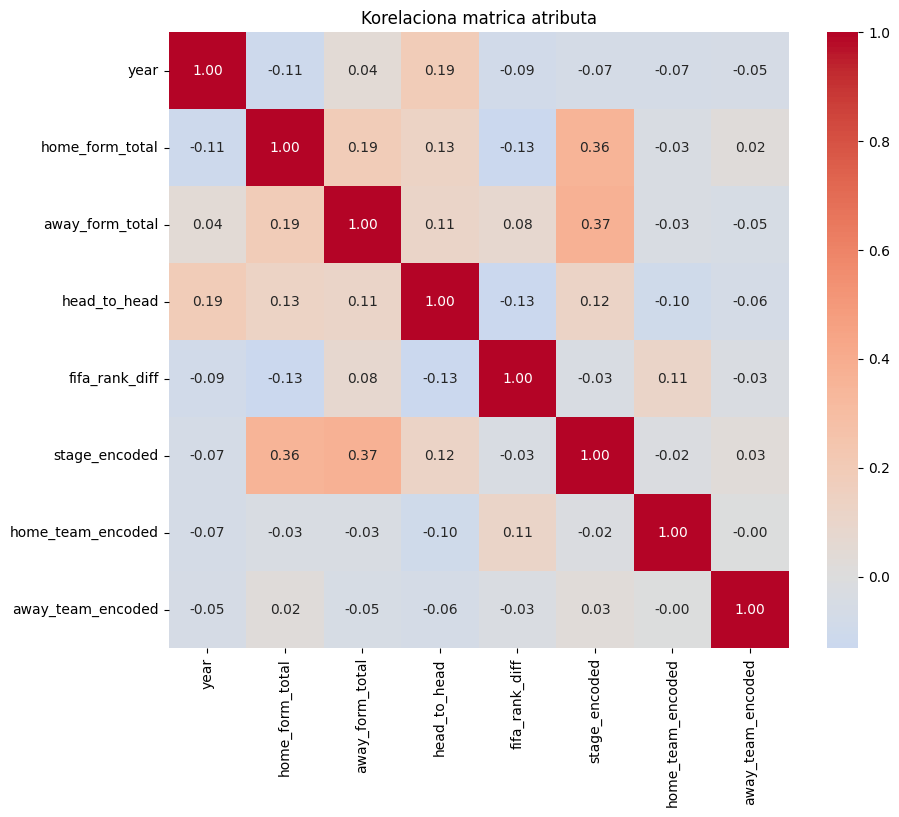

In [74]:
# Korelaciona matrica numeričkih atributa
import seaborn as sns
import matplotlib.pyplot as plt

numeric_cols = ['year', 'home_form_total', 'away_form_total', 'head_to_head', 
                'fifa_rank_diff', 'stage_encoded', 'home_team_encoded', 'away_team_encoded']

plt.figure(figsize=(10, 8))
sns.heatmap(df_final[numeric_cols].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Korelaciona matrica atributa')
plt.show()

In [75]:
# Priprema za trening

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Enkodiranje ciljne promenljive
le_result = LabelEncoder()
df_final['result_encoded'] = le_result.fit_transform(df_final['result'])

print("Mapiranje rezultata:")
for i, klasa in enumerate(le_result.classes_):
    print(f"  {klasa} -> {i}")

X = df_final.drop(['result', 'result_encoded'], axis=1)
y = df_final['result_encoded']

# Podela na trening i test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nUkupno utakmica: {len(df_final)}")
print(f"Trening skup (80%): {len(X_train)} utakmica")
print(f"Test skup (20%): {len(X_test)} utakmica")

# Skaliranje
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nPre skaliranja - mean: {X_train.mean().mean():.3f}")
print(f"Pre skaliranja - std:  {X_train.std().mean():.3f}")
print(f"Nakon skaliranja - mean: {X_train_scaled.mean():.3f}")
print(f"Nakon skaliranja - std:  {X_train_scaled.std():.3f}")

Mapiranje rezultata:
  away team win -> 0
  draw -> 1
  home team win -> 2

Ukupno utakmica: 1248
Trening skup (80%): 998 utakmica
Test skup (20%): 250 utakmica

Pre skaliranja - mean: 259.285
Pre skaliranja - std:  12.676
Nakon skaliranja - mean: -0.000
Nakon skaliranja - std:  1.000


In [76]:
# Trening modela

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

if isinstance(y_train.iloc[0], str):
    y_train_encoded = le_result.transform(y_train)
    y_test_encoded = le_result.transform(y_test)
else:
    y_train_encoded = y_train
    y_test_encoded = y_test

# Modeli
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, eval_metric='mlogloss', random_state=42)
}

results = []
best_model = None
best_accuracy = 0

for name, model in models.items():
    model.fit(X_train_scaled, y_train_encoded)
    y_pred = model.predict(X_test_scaled)
    acc = accuracy_score(y_test_encoded, y_pred)
    results.append((name, acc))
    
    if acc > best_accuracy:
        best_accuracy = acc
        best_model = name

print(f"{'Model':<20} {'Tačnost':<10}")

for name, acc in results:
    print(f"{name:<20} {acc:.2%}")

print(f"Najbolji model: {best_model}")
print(f"Tačnost: {best_accuracy:.2%}")

Model                Tačnost   
Logistic Regression  63.60%
Decision Tree        54.00%
Random Forest        59.60%
XGBoost              57.60%
Najbolji model: Logistic Regression
Tačnost: 63.60%


In [77]:
# Podešavanje hiperparametara - grid search

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

print("\nDefault model:")
logreg_default = LogisticRegression(random_state=42)
logreg_default.fit(X_train_scaled, y_train)
y_pred_default = logreg_default.predict(X_test_scaled)
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Tačnost: {acc_default:.4f} ({acc_default:.2%})")

#Grid search
param_grid = {
    'C': [0.01, 0.05, 0.1, 0.5, 1.0, 1.5, 2.0],
    'solver': ['lbfgs', 'newton-cg', 'sag', 'saga'],
    'max_iter': [500, 1000, 2000]
}

# GridSearch sa 5-strukom unakrsnom validacijom
grid_search = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

print("\nNajbolji parametri:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nNajbolja CV tačnost: {grid_search.best_score_:.4f} ({grid_search.best_score_:.2%})")

# Evaluacija podešenog modela na test skupu
best_logreg = grid_search.best_estimator_
y_pred_best = best_logreg.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)

# Poredjenje
print(f"Pre podešavanja: {acc_default:.4f} ({acc_default:.2%})")
print(f"Posle podešavanja:{acc_best:.4f} ({acc_best:.2%})")

if acc_best > acc_default:
    print("\nPodešavanje je poboljšalo model!")
else:
    print("\nPodešavanje nije donelo poboljšanje, ali smo potvrdili da je default model dobar.")

best_model = best_logreg


Default model:
Tačnost: 0.6360 (63.60%)

Najbolji parametri:
   C: 0.05
   max_iter: 500
   solver: lbfgs

Najbolja CV tačnost: 0.6182 (61.82%)
Pre podešavanja: 0.6360 (63.60%)
Posle podešavanja:0.6320 (63.20%)

Podešavanje nije donelo poboljšanje, ali smo potvrdili da je default model dobar.


In [78]:
# Logistic regresion sa ručnim podešavanjem klasa

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

class_weights_manual = {
    0: 1.0,    
    1: 1.7,    
    2: 1.0     
}

logreg_manual = LogisticRegression(class_weight=class_weights_manual, random_state=42, max_iter=1000)
logreg_manual.fit(X_train_scaled, y_train)
y_pred_manual = logreg_manual.predict(X_test_scaled)

print("\nIzveštaj:")
print(classification_report(y_test, y_pred_manual, target_names=['away win', 'draw', 'home win']))

acc_manual = accuracy_score(y_test, y_pred_manual)
print(f"\nTačnost: {acc_manual:.4f} ({acc_manual:.2%})")


Izveštaj:
              precision    recall  f1-score   support

    away win       0.67      0.42      0.51        67
        draw       0.22      0.10      0.13        42
    home win       0.63      0.85      0.73       141

    accuracy                           0.61       250
   macro avg       0.51      0.45      0.46       250
weighted avg       0.57      0.61      0.57       250


Tačnost: 0.6080 (60.80%)


In [79]:
# XGboost hiperparametri

from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings('ignore')

xgb_default = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_default.fit(X_train_scaled, y_train)
y_pred_default = xgb_default.predict(X_test_scaled)
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Tačnost pre podešavanja: {acc_default:.4f} ({acc_default:.2%})")

# Grid search

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

xgb = XGBClassifier(eval_metric='mlogloss', random_state=42)

grid_search = GridSearchCV(
    xgb, param_grid, 
    cv=3,  
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train_scaled, y_train)

# Rezultati
print("\nNajbolji parametri:")
for param, value in grid_search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nNajbolja CV tačnost: {grid_search.best_score_:.4f} ({grid_search.best_score_:.2%})")

# Test skup
best_xgb = grid_search.best_estimator_
y_pred_best = best_xgb.predict(X_test_scaled)
acc_best = accuracy_score(y_test, y_pred_best)

print(f"Pre podešavanja:  {acc_default:.4f} ({acc_default:.2%})")
print(f"Posle podešavanja: {acc_best:.4f} ({acc_best:.2%})")

print("Klasifikacioni izveštaj:")
print(classification_report(y_test, y_pred_best, target_names=['away win', 'draw', 'home win']))

Tačnost pre podešavanja: 0.5760 (57.60%)

Najbolji parametri:
   colsample_bytree: 0.7
   learning_rate: 0.01
   max_depth: 5
   n_estimators: 300
   subsample: 1.0

Najbolja CV tačnost: 0.6222 (62.22%)
Pre podešavanja:  0.5760 (57.60%)
Posle podešavanja: 0.6000 (60.00%)
Klasifikacioni izveštaj:
              precision    recall  f1-score   support

    away win       0.51      0.33      0.40        67
        draw       1.00      0.05      0.09        42
    home win       0.61      0.89      0.73       141

    accuracy                           0.60       250
   macro avg       0.71      0.42      0.41       250
weighted avg       0.65      0.60      0.53       250



Tačnost: 0.6080 (60.80%)

Izveštaj:
              precision    recall  f1-score   support

    away win       0.67      0.42      0.51        67
        draw       0.22      0.10      0.13        42
    home win       0.63      0.85      0.73       141

    accuracy                           0.61       250
   macro avg       0.51      0.45      0.46       250
weighted avg       0.57      0.61      0.57       250



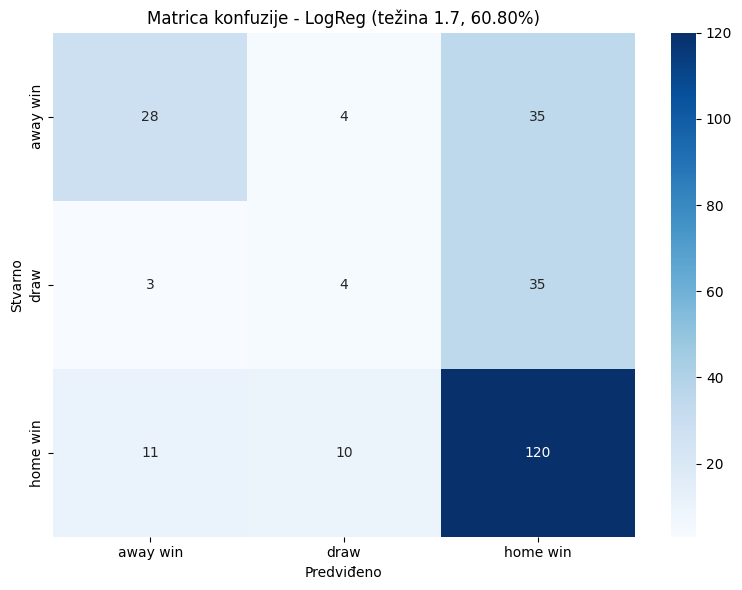

In [80]:
# Logistic regresion

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_logreg = logreg_manual.predict(X_test_scaled)
acc_logreg = accuracy_score(y_test, y_pred_logreg)

print(f"Tačnost: {acc_logreg:.4f} ({acc_logreg:.2%})")
print("\nIzveštaj:")
print(classification_report(y_test, y_pred_logreg, target_names=['away win', 'draw', 'home win']))

# Matrica konfuzije
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Blues',
            xticklabels=['away win', 'draw', 'home win'],
            yticklabels=['away win', 'draw', 'home win'])
plt.title('Matrica konfuzije - LogReg (težina 1.7, 60.80%)')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.tight_layout()
plt.show()

Tačnost: 0.6000 (60.00%)

Izveštaj:
              precision    recall  f1-score   support

    away win       0.51      0.33      0.40        67
        draw       1.00      0.05      0.09        42
    home win       0.61      0.89      0.73       141

    accuracy                           0.60       250
   macro avg       0.71      0.42      0.41       250
weighted avg       0.65      0.60      0.53       250



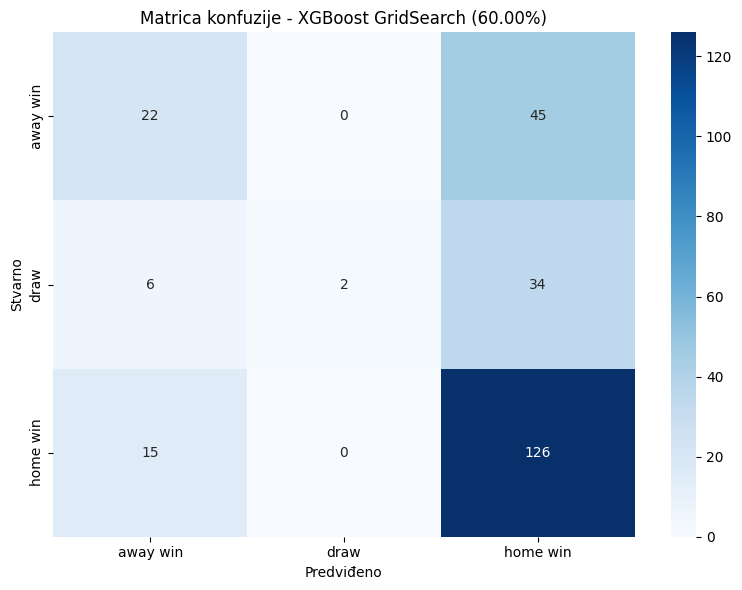

In [81]:
# Grid search report

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_xgb = grid_search.best_estimator_.predict(X_test_scaled)
acc_xgb = accuracy_score(y_test, y_pred_xgb)

print(f"Tačnost: {acc_xgb:.4f} ({acc_xgb:.2%})")
print("\nIzveštaj:")
print(classification_report(y_test, y_pred_xgb, target_names=['away win', 'draw', 'home win']))

# Matrica konfuzije
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['away win', 'draw', 'home win'],
            yticklabels=['away win', 'draw', 'home win'])
plt.title('Matrica konfuzije - XGBoost GridSearch (60.00%)')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.tight_layout()
plt.show()

year                     : +0.4790
fifa_rank_diff           : +0.3885
stage_encoded            : +0.3254
away_form_total          : +0.2884
home_form_total          : -0.2122
away_team_encoded        : +0.1156
head_to_head             : -0.0210
home_team_encoded        : -0.0012


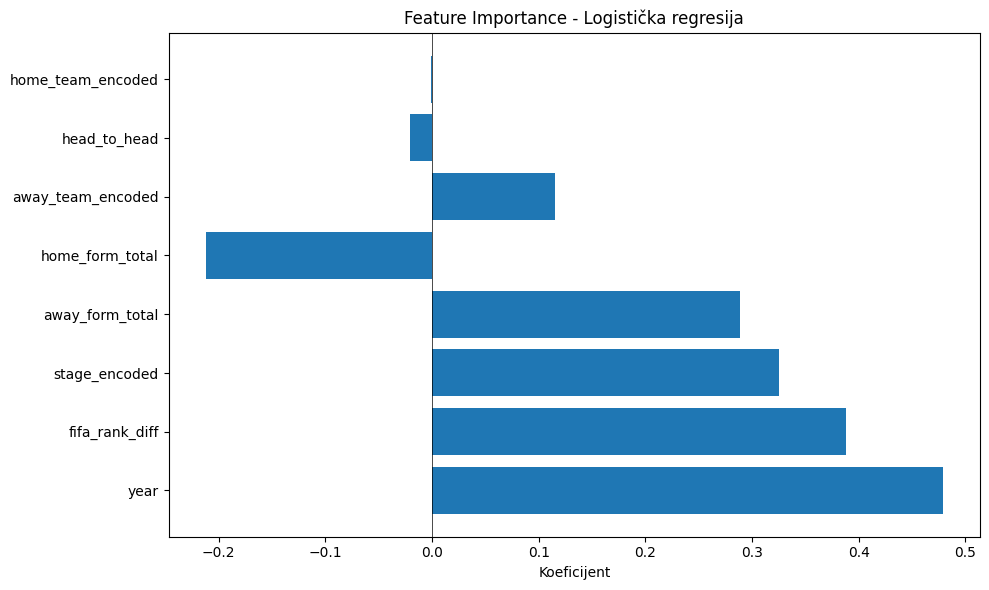

In [86]:
# FEATURE IMPORTANCE - NAJBOLJI MODEL (LogReg težina 1.7)

coef = logreg_manual.coef_[0]
feature_names = X_train.columns.tolist()

importance_df = pd.DataFrame({
    'Atribut': feature_names,
    'Koeficijent': coef
}).sort_values('Koeficijent', key=abs, ascending=False)


for _, row in importance_df.iterrows():
    znak = "+" if row['Koeficijent'] > 0 else "-"
    print(f"{row['Atribut']:25s}: {znak}{abs(row['Koeficijent']):.4f}")

# Grafički prikaz

import matplotlib.pyplot as plt
import seaborn as sns

# Koeficijenti modela
coef = logreg_manual.coef_[0]
feature_names = X_train.columns.tolist()

# DataFrame
importance_df = pd.DataFrame({
    'Atribut': feature_names,
    'Koeficijent': coef
}).sort_values('Koeficijent', key=abs, ascending=False)

# Jednostavniji grafik
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Atribut'], importance_df['Koeficijent'])
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Koeficijent')
plt.title('Feature Importance - Logistička regresija')
plt.tight_layout()
plt.show()

In [59]:
# POREDJENJE: SVI ATRIBUTI vs TOP 3 ATRIBUTA

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

top_3 = ['year', 'fifa_rank_diff', 'stage_encoded']

X_train_top = X_train[top_3]
X_test_top = X_test[top_3]

scaler_top = StandardScaler()
X_train_top_scaled = scaler_top.fit_transform(X_train_top)
X_test_top_scaled = scaler_top.transform(X_test_top)

logreg_top = LogisticRegression(class_weight={0:1.0, 1:1.7, 2:1.0}, random_state=42, max_iter=1000)
logreg_top.fit(X_train_top_scaled, y_train)
y_pred_top = logreg_top.predict(X_test_top_scaled)
acc_top = accuracy_score(y_test, y_pred_top)

print(f"Tačnost sa SVIH 8 atributa: {acc_manual:.4f} ({acc_manual:.2%})")
print(f"Tačnost sa TOP 3 atributa:   {acc_top:.4f} ({acc_top:.2%})")
print(f"Razlika: {(acc_manual - acc_top)*100:.2f}%")

Tačnost sa SVIH 8 atributa: 0.6080 (60.80%)
Tačnost sa TOP 3 atributa:   0.6200 (62.00%)
Razlika: -1.20%


Ukupna tačnost: 0.6200 (62.00%)

Izveštaj:
              precision    recall  f1-score   support

    away win       0.63      0.40      0.49        67
        draw       0.00      0.00      0.00        42
    home win       0.62      0.91      0.74       141

    accuracy                           0.62       250
   macro avg       0.42      0.44      0.41       250
weighted avg       0.52      0.62      0.55       250



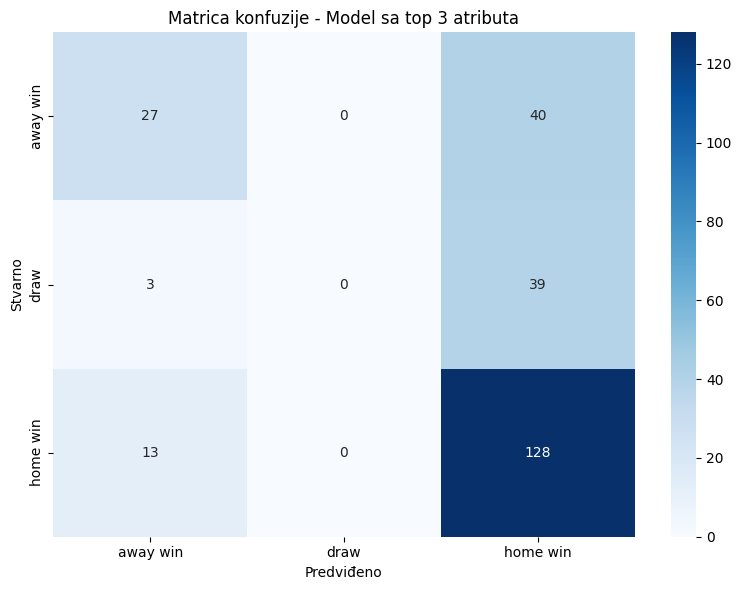

In [64]:
# Evaluacija top 3
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Podaci samo za top 3 atributa
final_features = ['year', 'fifa_rank_diff', 'stage_encoded']
X_final = X[final_features]

# Podela
X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y
)

# Skaliranje
scaler_final = StandardScaler()
X_train_final_scaled = scaler_final.fit_transform(X_train_final)
X_test_final_scaled = scaler_final.transform(X_test_final)

# Treniranje
logreg_final = LogisticRegression(class_weight={0:1.0, 1:1.7, 2:1.0}, random_state=42, max_iter=1000)
logreg_final.fit(X_train_final_scaled, y_train_final)

# Predikcije
y_pred_final = logreg_final.predict(X_test_final_scaled)
y_proba_final = logreg_final.predict_proba(X_test_final_scaled)

# Ukupna tačnost
acc_final = accuracy_score(y_test_final, y_pred_final)

print(f"Ukupna tačnost: {acc_final:.4f} ({acc_final:.2%})")

# Classification report
print("\nIzveštaj:")
print(classification_report(y_test_final, y_pred_final, 
                           target_names=['away win', 'draw', 'home win']))

# Matrica konfuzije
cm = confusion_matrix(y_test_final, y_pred_final)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['away win', 'draw', 'home win'],
            yticklabels=['away win', 'draw', 'home win'])
plt.title('Matrica konfuzije - Model sa top 3 atributa')
plt.xlabel('Predviđeno')
plt.ylabel('Stvarno')
plt.tight_layout()
plt.show()

In [65]:
# Eksportovanje finalnog modela

import joblib
import os

# Eksportovanje modela, skalera i label enkodera
joblib.dump(logreg_manual, 'models/final_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')
joblib.dump(le_result, 'models/label_encoder.pkl')

['models/label_encoder.pkl']

In [66]:
import joblib

# Sačuvaj originalne enkodere
joblib.dump(le_home, 'models/le_home.pkl')
joblib.dump(le_away, 'models/le_away.pkl')

['models/le_away.pkl']